In [3]:
!pip install ultralytics opencv-python streamlit plotly pandas numpy pillow --quiet

In [ ]:

import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO 
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")
print("✅ YOLO imported from ultralytics")

✅ Libraries loaded successfully
✅ YOLO imported from ultralytics


In [ ]:

model = YOLO('yolov8n.pt') 

print("✅ YOLOv8 model loaded")
print(f"Model can detect: {len(model.names)} classes")
print(f"Classes include: {list(model.names.values())[:10]}...")  

✅ YOLOv8 model loaded
Model can detect: 80 classes
Classes include: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']...


In [ ]:
def generate_synthetic_traffic_data(hours=24):
    """
    Generate realistic 24-hour traffic patterns for Indian cities
    Based on actual traffic studies from Ahmedabad, Delhi, Bengaluru
    """
    timestamps = []
    people = []
    vehicles = []
    
    # Generate data points every 5 minutes for 24 hours
    for hour in range(hours):
        for minute in range(0, 60, 5):
            time = datetime(2026, 2, 12, hour, minute)
            timestamps.append(time)
            
            
            if 6 <= hour <= 9:  # Morning rush (6 AM - 9 AM)
                people.append(np.random.randint(20, 50))
                vehicles.append(np.random.randint(40, 80))
                
            elif 17 <= hour <= 20:  # Evening rush (5 PM - 8 PM)
                people.append(np.random.randint(25, 55))
                vehicles.append(np.random.randint(50, 90))
                
            elif 12 <= hour <= 14:  # Lunch time (12 PM - 2 PM)
                people.append(np.random.randint(10, 30))
                vehicles.append(np.random.randint(20, 40))
                
            elif 21 <= hour <= 23:  # Late evening (9 PM - 11 PM)
                people.append(np.random.randint(5, 15))
                vehicles.append(np.random.randint(10, 25))
                
            elif 0 <= hour <= 5:  # Night/early morning (12 AM - 5 AM)
                people.append(np.random.randint(0, 5))
                vehicles.append(np.random.randint(0, 10))
                
            else:  # Normal hours (9 AM - 12 PM, 2 PM - 5 PM)
                people.append(np.random.randint(8, 25))
                vehicles.append(np.random.randint(15, 35))
    
    df = pd.DataFrame({
        'timestamp': timestamps,
        'people_count': people,
        'vehicle_count': vehicles,
        'total_activity': np.array(people) + np.array(vehicles)
    })
    
    return df

# Generate synthetic data
df_traffic = generate_synthetic_traffic_data(hours=24)

print(f"✅ Generated {len(df_traffic)} data points (24 hours, every 5 minutes)")
print(f"📊 Activity range: {df_traffic['total_activity'].min()} - {df_traffic['total_activity'].max()}")
print("\nFirst 10 rows:")
df_traffic.head(10)

✅ Generated 288 data points (24 hours, every 5 minutes)
📊 Activity range: 0 - 136

First 10 rows:


,timestamp,people_count,vehicle_count,total_activity
0,2026-02-12 00:00:00,3,7,10
1,2026-02-12 00:05:00,2,0,2
2,2026-02-12 00:10:00,3,0,3
3,2026-02-12 00:15:00,1,2,3
4,2026-02-12 00:20:00,3,5,8
5,2026-02-12 00:25:00,2,2,4
6,2026-02-12 00:30:00,2,2,4
7,2026-02-12 00:35:00,3,6,9
8,2026-02-12 00:40:00,1,2,3
9,2026-02-12 00:45:00,3,1,4


In [7]:
def calculate_brightness_levels(df):
    """
    Calculate optimal brightness based on activity level
    
    Brightness Rules (based on safety requirements):
    - 0-5 people/vehicles: 20% (minimal activity)
    - 6-15: 40% (low activity)
    - 16-30: 60% (moderate activity)
    - 31-50: 80% (high activity)
    - 51+: 100% (peak activity)
    """
    def activity_to_brightness(activity):
        if activity <= 5:
            return 20
        elif activity <= 15:
            return 40
        elif activity <= 30:
            return 60
        elif activity <= 50:
            return 80
        else:
            return 100
    
    # Apply brightness calculation
    df['optimal_brightness'] = df['total_activity'].apply(activity_to_brightness)
    
    # Traditional system always at 100%
    df['traditional_brightness'] = 100
    
    # Calculate energy consumption ratio
    df['energy_ratio'] = df['optimal_brightness'] / df['traditional_brightness']
    
    return df

# Apply brightness calculation
df_traffic = calculate_brightness_levels(df_traffic)

# Show brightness distribution
brightness_dist = df_traffic['optimal_brightness'].value_counts().sort_index()
print("✅ Brightness levels calculated")
print("\n📊 Brightness Distribution:")
for brightness, count in brightness_dist.items():
    percentage = (count / len(df_traffic)) * 100
    print(f"  {brightness}% brightness: {count} periods ({percentage:.1f}% of time)")

df_traffic.head(10)

✅ Brightness levels calculated

📊 Brightness Distribution:
  20% brightness: 31 periods (10.8% of time)
  40% brightness: 41 periods (14.2% of time)
  60% brightness: 34 periods (11.8% of time)
  80% brightness: 65 periods (22.6% of time)
  100% brightness: 117 periods (40.6% of time)


,timestamp,people_count,vehicle_count,total_activity,optimal_brightness,traditional_brightness,energy_ratio
0,2026-02-12 00:00:00,3,7,10,40,100,0.4
1,2026-02-12 00:05:00,2,0,2,20,100,0.2
2,2026-02-12 00:10:00,3,0,3,20,100,0.2
3,2026-02-12 00:15:00,1,2,3,20,100,0.2
4,2026-02-12 00:20:00,3,5,8,40,100,0.4
5,2026-02-12 00:25:00,2,2,4,20,100,0.2
6,2026-02-12 00:30:00,2,2,4,20,100,0.2
7,2026-02-12 00:35:00,3,6,9,40,100,0.4
8,2026-02-12 00:40:00,1,2,3,20,100,0.2
9,2026-02-12 00:45:00,3,1,4,20,100,0.2


In [8]:
def calculate_savings(df, num_streetlights=100, power_per_light=150, hours_per_day=24):
    """
    Calculate comprehensive energy and cost savings
    
    Args:
        df: DataFrame with brightness data
        num_streetlights: Number of lights in the zone
        power_per_light: Watts per streetlight (typical LED = 150W)
        hours_per_day: Hours of operation (24 for all night)
    
    Returns:
        Dictionary with detailed savings metrics
    """
    # Time interval between data points (minutes)
    time_interval_minutes = 5
    hours_interval = time_interval_minutes / 60
    
    # Traditional system: 100% brightness always
    traditional_kwh_per_day = (num_streetlights * power_per_light * 
                               len(df) * hours_interval) / 1000
    
    # Smart system: variable brightness
    total_brightness_hours = (df['optimal_brightness'].sum() / 100) * hours_interval
    smart_kwh_per_day = (num_streetlights * power_per_light * 
                         total_brightness_hours) / 1000
    
    # Calculate savings
    kwh_saved_per_day = traditional_kwh_per_day - smart_kwh_per_day
    percentage_saved = (kwh_saved_per_day / traditional_kwh_per_day) * 100
    
    # Cost calculations (₹7 per kWh - typical municipal rate in India)
    cost_per_kwh = 7
    cost_saved_per_day = kwh_saved_per_day * cost_per_kwh
    cost_saved_per_month = cost_saved_per_day * 30
    cost_saved_per_year = cost_saved_per_day * 365
    
    # Environmental impact (0.82 kg CO2 per kWh in India's grid mix)
    co2_saved_kg_per_day = kwh_saved_per_day * 0.82
    co2_saved_kg_per_year = co2_saved_kg_per_day * 365
    
    # Trees equivalent (one tree absorbs ~20kg CO2/year)
    trees_equivalent = co2_saved_kg_per_year / 20
    
    return {
        'traditional_kwh_per_day': traditional_kwh_per_day,
        'smart_kwh_per_day': smart_kwh_per_day,
        'kwh_saved_per_day': kwh_saved_per_day,
        'percentage_saved': percentage_saved,
        'cost_saved_per_day': cost_saved_per_day,
        'cost_saved_per_month': cost_saved_per_month,
        'cost_saved_per_year': cost_saved_per_year,
        'co2_saved_kg_per_day': co2_saved_kg_per_day,
        'co2_saved_kg_per_year': co2_saved_kg_per_year,
        'trees_equivalent': trees_equivalent,
        'num_streetlights': num_streetlights,
        'power_per_light': power_per_light
    }

# Calculate savings for 100 streetlights
savings = calculate_savings(df_traffic, num_streetlights=100, power_per_light=150)

# Display results
print("=" * 60)
print("💡 LUMI-NODE IMPACT ANALYSIS")
print("=" * 60)
print(f"\n🔋 ENERGY SAVINGS:")
print(f"  Traditional System: {savings['traditional_kwh_per_day']:.2f} kWh/day")
print(f"  Smart System:       {savings['smart_kwh_per_day']:.2f} kWh/day")
print(f"  Energy Saved:       {savings['kwh_saved_per_day']:.2f} kWh/day ({savings['percentage_saved']:.1f}%)")

print(f"\n💰 COST SAVINGS:")
print(f"  Daily:   ₹{savings['cost_saved_per_day']:,.2f}")
print(f"  Monthly: ₹{savings['cost_saved_per_month']:,.2f}")
print(f"  Yearly:  ₹{savings['cost_saved_per_year']:,.2f}")

print(f"\n🌍 ENVIRONMENTAL IMPACT:")
print(f"  CO₂ Saved:         {savings['co2_saved_kg_per_year']:,.0f} kg/year")
print(f"  Trees Equivalent:  {savings['trees_equivalent']:.0f} trees")

print(f"\n⚙️ SYSTEM CONFIGURATION:")
print(f"  Streetlights: {savings['num_streetlights']}")
print(f"  Power/Light:  {savings['power_per_light']}W")
print("=" * 60)

💡 LUMI-NODE IMPACT ANALYSIS

🔋 ENERGY SAVINGS:
  Traditional System: 360.00 kWh/day
  Smart System:       265.00 kWh/day
  Energy Saved:       95.00 kWh/day (26.4%)

💰 COST SAVINGS:
  Daily:   ₹665.00
  Monthly: ₹19,950.00
  Yearly:  ₹242,725.00

🌍 ENVIRONMENTAL IMPACT:
  CO₂ Saved:         28,434 kg/year
  Trees Equivalent:  1422 trees

⚙️ SYSTEM CONFIGURATION:
  Streetlights: 100
  Power/Light:  150W


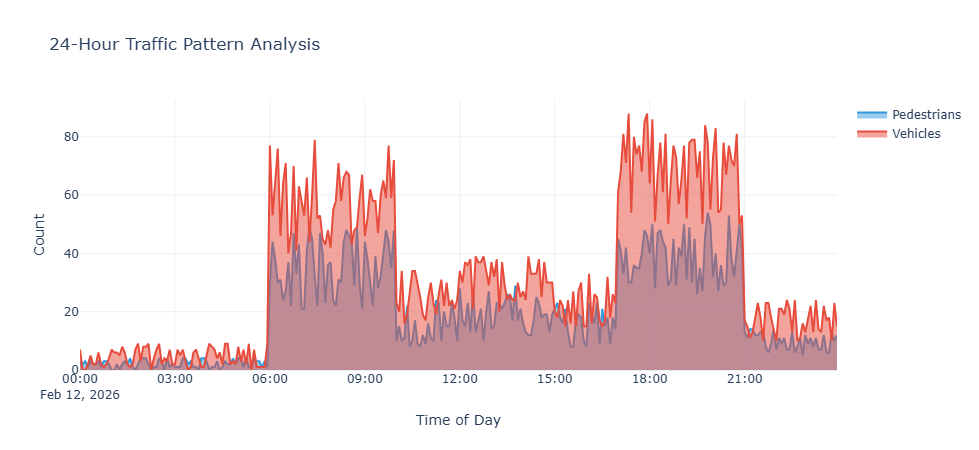

✅ Chart 1: Traffic Pattern


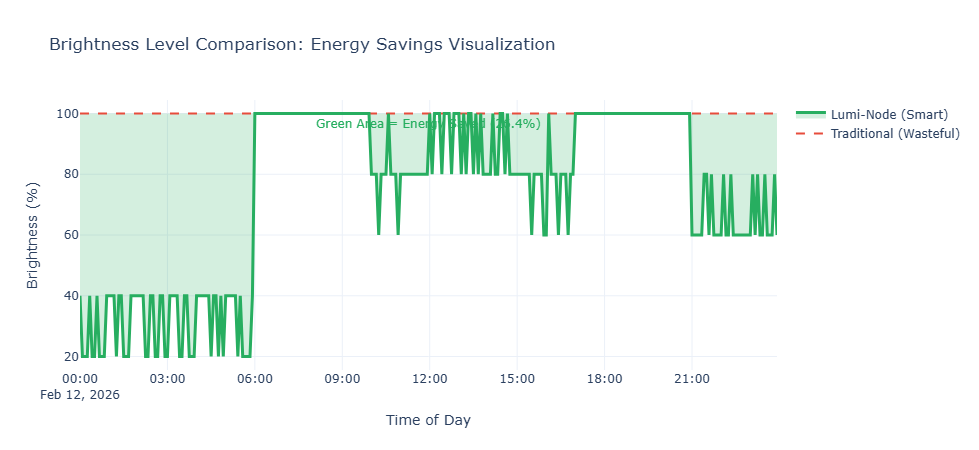

✅ Chart 2: Brightness Comparison


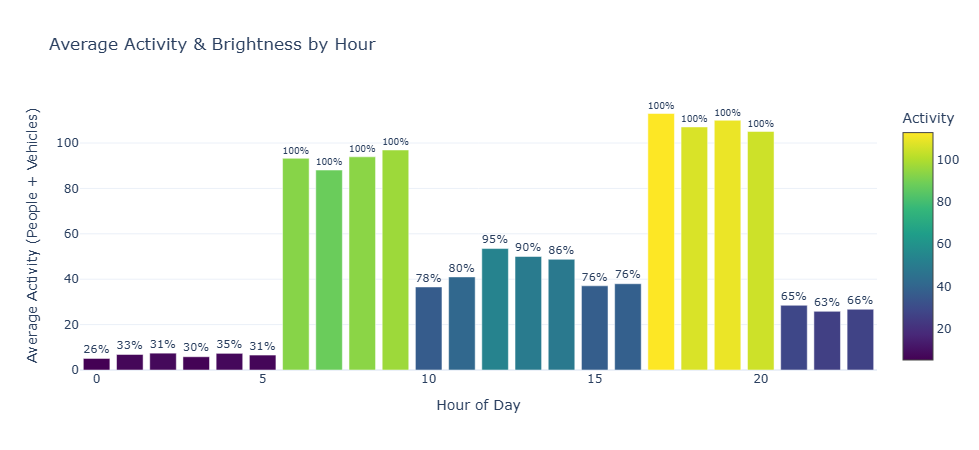

✅ Chart 3: Hourly Analysis


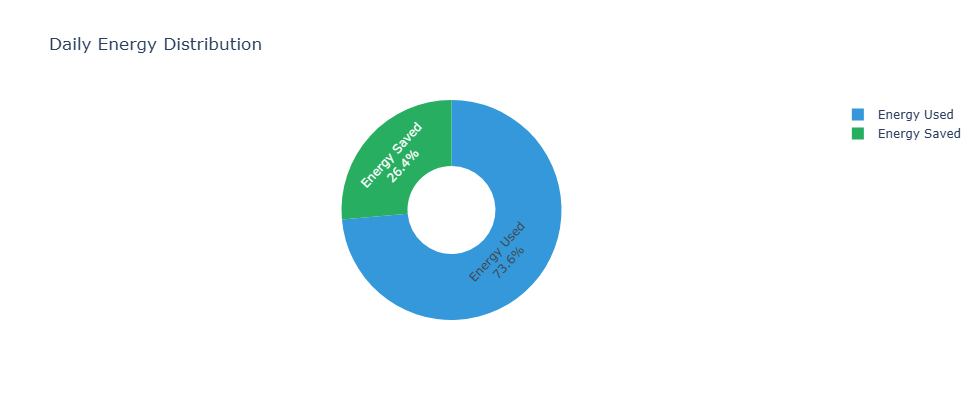

✅ Chart 4: Energy Distribution

✅ All visualizations created successfully!


In [9]:
# Create visualizations

# 1. Traffic Pattern Over 24 Hours
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=df_traffic['timestamp'],
    y=df_traffic['people_count'],
    name='Pedestrians',
    line=dict(color='#3498db', width=2),
    fill='tozeroy'
))

fig1.add_trace(go.Scatter(
    x=df_traffic['timestamp'],
    y=df_traffic['vehicle_count'],
    name='Vehicles',
    line=dict(color='#e74c3c', width=2),
    fill='tozeroy'
))

fig1.update_layout(
    title='24-Hour Traffic Pattern Analysis',
    xaxis_title='Time of Day',
    yaxis_title='Count',
    height=450,
    hovermode='x unified',
    template='plotly_white'
)

fig1.show()

print("✅ Chart 1: Traffic Pattern")

# 2. Brightness Comparison: Traditional vs Smart
fig2 = go.Figure()

# Fill area between curves to show savings
fig2.add_trace(go.Scatter(
    x=df_traffic['timestamp'],
    y=df_traffic['traditional_brightness'],
    name='Traditional (Wasteful)',
    line=dict(color='#e74c3c', width=2, dash='dash'),
    fill=None
))

fig2.add_trace(go.Scatter(
    x=df_traffic['timestamp'],
    y=df_traffic['optimal_brightness'],
    name='Lumi-Node (Smart)',
    line=dict(color='#27ae60', width=3),
    fill='tonexty',  # Fill to previous trace
    fillcolor='rgba(39, 174, 96, 0.2)'
))

fig2.update_layout(
    title='Brightness Level Comparison: Energy Savings Visualization',
    xaxis_title='Time of Day',
    yaxis_title='Brightness (%)',
    height=450,
    hovermode='x unified',
    template='plotly_white',
    annotations=[
        dict(
            x=0.5, y=0.95,
            xref='paper', yref='paper',
            text=f'Green Area = Energy Saved ({savings["percentage_saved"]:.1f}%)',
            showarrow=False,
            font=dict(size=12, color='#27ae60')
        )
    ]
)

fig2.show()

print("✅ Chart 2: Brightness Comparison")

# 3. Hourly Activity Heatmap
df_traffic['hour'] = df_traffic['timestamp'].dt.hour
hourly_avg = df_traffic.groupby('hour').agg({
    'total_activity': 'mean',
    'optimal_brightness': 'mean'
}).reset_index()

fig3 = go.Figure()

fig3.add_trace(go.Bar(
    x=hourly_avg['hour'],
    y=hourly_avg['total_activity'],
    name='Activity Level',
    marker=dict(
        color=hourly_avg['total_activity'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Activity")
    ),
    text=hourly_avg['optimal_brightness'].astype(int).astype(str) + '%',
    textposition='outside'
))

fig3.update_layout(
    title='Average Activity & Brightness by Hour',
    xaxis_title='Hour of Day',
    yaxis_title='Average Activity (People + Vehicles)',
    height=450,
    template='plotly_white'
)

fig3.show()

print("✅ Chart 3: Hourly Analysis")

# 4. Energy Consumption Comparison (Pie Chart)
energy_comparison = pd.DataFrame({
    'System': ['Energy Saved', 'Energy Used'],
    'kWh': [savings['kwh_saved_per_day'], savings['smart_kwh_per_day']]
})

fig4 = px.pie(
    energy_comparison,
    values='kWh',
    names='System',
    title='Daily Energy Distribution',
    color='System',
    color_discrete_map={'Energy Saved': '#27ae60', 'Energy Used': '#3498db'},
    hole=0.4
)

fig4.update_traces(textposition='inside', textinfo='percent+label')
fig4.update_layout(height=400)

fig4.show()

print("✅ Chart 4: Energy Distribution")

print("\n✅ All visualizations created successfully!")

In [10]:
# Save processed data for Streamlit dashboard

# 1. Save traffic analysis data
df_traffic.to_csv('traffic_analysis.csv', index=False)
print("✅ Saved: traffic_analysis.csv")

# 2. Save savings metrics
savings_df = pd.DataFrame([savings])
savings_df.to_csv('savings_metrics.csv', index=False)
print("✅ Saved: savings_metrics.csv")

# 3. Create hourly summary
hourly_summary = df_traffic.groupby('hour').agg({
    'people_count': 'mean',
    'vehicle_count': 'mean',
    'total_activity': 'mean',
    'optimal_brightness': 'mean'
}).round(2).reset_index()

hourly_summary.to_csv('hourly_summary.csv', index=False)
print("✅ Saved: hourly_summary.csv")

# Display summary statistics
print("\n📊 DATA SUMMARY:")
print(f"  Total Data Points: {len(df_traffic)}")
print(f"  Time Range: {df_traffic['timestamp'].min()} to {df_traffic['timestamp'].max()}")
print(f"  Average Activity: {df_traffic['total_activity'].mean():.1f} people/vehicles")
print(f"  Peak Activity: {df_traffic['total_activity'].max()} at {df_traffic.loc[df_traffic['total_activity'].idxmax(), 'timestamp']}")
print(f"  Lowest Activity: {df_traffic['total_activity'].min()} at {df_traffic.loc[df_traffic['total_activity'].idxmin(), 'timestamp']}")

print("\n✅ All data exported successfully!")
print("🚀 Ready to launch Streamlit dashboard!")

✅ Saved: traffic_analysis.csv
✅ Saved: savings_metrics.csv
✅ Saved: hourly_summary.csv

📊 DATA SUMMARY:
  Total Data Points: 288
  Time Range: 2026-02-12 00:00:00 to 2026-02-12 23:55:00
  Average Activity: 51.4 people/vehicles
  Peak Activity: 136 at 2026-02-12 18:05:00
  Lowest Activity: 0 at 2026-02-12 02:15:00

✅ All data exported successfully!
🚀 Ready to launch Streamlit dashboard!


In [11]:
# Final data preview and validation

print("📊 FINAL DATA PREVIEW:")
print("\n" + "="*80)
print(df_traffic.head(20).to_string(index=False))
print("="*80)

print(f"\n📈 BRIGHTNESS STATISTICS:")
print(df_traffic['optimal_brightness'].describe())

print(f"\n✅ Data validation complete!")
print(f"   Files ready for Streamlit: traffic_analysis.csv, savings_metrics.csv")

📊 FINAL DATA PREVIEW:

          timestamp  people_count  vehicle_count  total_activity  optimal_brightness  traditional_brightness  energy_ratio  hour
2026-02-12 00:00:00             3              7              10                  40                     100           0.4     0
2026-02-12 00:05:00             2              0               2                  20                     100           0.2     0
2026-02-12 00:10:00             3              0               3                  20                     100           0.2     0
2026-02-12 00:15:00             1              2               3                  20                     100           0.2     0
2026-02-12 00:20:00             3              5               8                  40                     100           0.4     0
2026-02-12 00:25:00             2              2               4                  20                     100           0.2     0
2026-02-12 00:30:00             2              2               4          